In [1]:
from dotenv import load_dotenv
import os
import requests

In [3]:
import numpy as np
import pandas as pd
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
import requests

climate_api = "https://api.mosqlimate.org/api/datastore/climate"

page = 1 # total amount of pages is returned in the request
per_page = 100
pagination = f"?page={page}&per_page={per_page}&"
filters = "start=%s&end=%s" % ("2016-01-01", "2024-12-31")

resp = requests.get(climate_api + pagination + filters)

load_dotenv(encoding="utf-16")

api_key = os.getenv("MOSQLIMATE_API_KEY")

headers = {
    "X-UID-Key": api_key
}

# Or you can add a geocode to the filters
geocode = 1302603
resp = requests.get(
    climate_api + 
    pagination + 
    filters +
    f"&geocode={geocode}",
    headers=headers
)

items = resp.json()["items"] # JSON data in dict format
#total_items = resp.json()["total_items"] # JSON data in dict format
resp.json()["pagination"] # Pagination*

{'items': 100,
 'total_items': 3288,
 'page': 1,
 'total_pages': 33,
 'per_page': 100}

In [4]:
#### Getting the full data:

pages = np.arange(1, 34) # total amount of pages is returned in the request
per_page = 100
for page in pages:
    pagination = f"?page={page}&per_page={per_page}&"
    filters = "start=%s&end=%s" % ("2016-01-01", "2024-12-31")

    resp = requests.get(climate_api + pagination + filters)

# Or you can add a geocode to the filters
geocode = 1302603
resp = requests.get(
    climate_api + 
    pagination + 
    filters +
    f"&geocode={geocode}",
    headers=headers
)

items = resp.json()["items"] # JSON data in dict format
#total_items = resp.json()["total_items"] # JSON data in dict format
resp.json()["pagination"] # Pagination*

{'items': 88,
 'total_items': 3288,
 'page': 33,
 'total_pages': 33,
 'per_page': 100}

In [5]:
total_pages = 33 

start_date = "2016-01-01"
end_date = "2024-12-31"

geocode = 1302603

all_items = []  # List to store all items

# Loop through each page
for page in range(1, total_pages + 1):
    pagination = f"?page={page}&per_page={per_page}&"
    filters = f"start={start_date}&end={end_date}&geocode={geocode}"
    
    resp = requests.get(climate_api + pagination + filters, headers=headers)
    
    # Check if the request was successful
    if resp.status_code == 200:
        items = resp.json().get("items", [])  # Get items, default to an empty list if key not found
        all_items.extend(items)  # Append the items from this page to the list
    else:
        print(f"Failed to retrieve data for page {page}")
        break  # Break the loop in case of a failed request

full_data_df = pd.DataFrame(all_items)
full_data_df

,date,geocodigo,epiweek,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,precip_tot,pressao_min,pressao_med,pressao_max,umid_min,umid_med,umid_max
0,2016-01-01,1302603,201552,25.2045,26.9742,28.7045,0.2092,3.0621,6.9870,24.4965,0.9865,0.9892,0.9912,73.5599,83.5514,91.6022
1,2016-01-02,1302603,201552,24.7094,25.7935,26.7381,0.0388,7.8986,17.6067,63.1887,0.9880,0.9899,0.9922,86.0326,90.3434,95.2309
2,2016-01-03,1302603,201601,24.1877,25.8707,28.2754,1.1520,7.2728,20.6599,58.1821,0.9870,0.9897,0.9917,79.3838,90.4124,97.3460
3,2016-01-04,1302603,201601,24.2683,26.5175,29.6513,0.1548,6.1504,12.8499,49.2032,0.9866,0.9893,0.9914,72.0116,87.7519,96.4379
4,2016-01-05,1302603,201601,25.3694,27.0980,29.6138,0.0445,3.3259,8.8127,26.6074,0.9882,0.9898,0.9919,70.6908,85.9048,96.4212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3283,2024-12-27,1302603,202452,24.3396,26.3144,29.6464,0.4375,4.4175,12.0925,35.3399,0.9873,0.9892,0.9908,72.7873,88.5445,95.8023
3284,2024-12-28,1302603,202452,24.6078,26.4918,30.1530,0.8793,4.4093,13.8036,35.2744,0.9871,0.9898,0.9916,69.3192,88.2399,96.5652
3285,2024-12-29,1302603,202501,25.0180,26.4557,28.5187,0.3675,5.6817,16.5503,45.4533,0.9875,0.9896,0.9918,80.2842,89.0658,94.7284
3286,2024-12-30,1302603,202501,24.1221,25.7000,27.6957,0.1818,5.2545,16.7795,42.0363,0.9868,0.9894,0.9913,80.0111,89.6784,96.1786


In [6]:
# Saves the dataframe as a separate csv file to be used in different modules
full_data_df.to_csv("../data/climate_api_data_2016_2024.csv", index=False)

In [7]:
datetime_df = pd.DataFrame()
datetime_df['date'] = pd.to_datetime(full_data_df['date'])

# Extract the year from the 'date' column
datetime_df['year'] = datetime_df['date'].dt.year

# Count the occurrences of each year
year_counts = datetime_df['year'].value_counts().sort_index()

print(year_counts)

year
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
Name: count, dtype: int64


In [8]:
full_data_df['days'] = (pd.to_datetime(full_data_df['date']) - pd.to_datetime(full_data_df['date'].iloc[int(0)])).dt.days
full_data_df

,date,geocodigo,epiweek,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,precip_tot,pressao_min,pressao_med,pressao_max,umid_min,umid_med,umid_max,days
0,2016-01-01,1302603,201552,25.2045,26.9742,28.7045,0.2092,3.0621,6.9870,24.4965,0.9865,0.9892,0.9912,73.5599,83.5514,91.6022,0
1,2016-01-02,1302603,201552,24.7094,25.7935,26.7381,0.0388,7.8986,17.6067,63.1887,0.9880,0.9899,0.9922,86.0326,90.3434,95.2309,1
2,2016-01-03,1302603,201601,24.1877,25.8707,28.2754,1.1520,7.2728,20.6599,58.1821,0.9870,0.9897,0.9917,79.3838,90.4124,97.3460,2
3,2016-01-04,1302603,201601,24.2683,26.5175,29.6513,0.1548,6.1504,12.8499,49.2032,0.9866,0.9893,0.9914,72.0116,87.7519,96.4379,3
4,2016-01-05,1302603,201601,25.3694,27.0980,29.6138,0.0445,3.3259,8.8127,26.6074,0.9882,0.9898,0.9919,70.6908,85.9048,96.4212,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3283,2024-12-27,1302603,202452,24.3396,26.3144,29.6464,0.4375,4.4175,12.0925,35.3399,0.9873,0.9892,0.9908,72.7873,88.5445,95.8023,3283
3284,2024-12-28,1302603,202452,24.6078,26.4918,30.1530,0.8793,4.4093,13.8036,35.2744,0.9871,0.9898,0.9916,69.3192,88.2399,96.5652,3284
3285,2024-12-29,1302603,202501,25.0180,26.4557,28.5187,0.3675,5.6817,16.5503,45.4533,0.9875,0.9896,0.9918,80.2842,89.0658,94.7284,3285
3286,2024-12-30,1302603,202501,24.1221,25.7000,27.6957,0.1818,5.2545,16.7795,42.0363,0.9868,0.9894,0.9913,80.0111,89.6784,96.1786,3286


In [9]:
def sinusoidal_parham_michael(x, A, omega, phi, C):
    return C * (1 + A * np.cos(omega * x - phi))

#### A = T2, R2
#### C = T1, R1

In [10]:
# Fitting the Parham & Michael model to the mean temperature data
params_temp_pm, _ = curve_fit(sinusoidal_parham_michael, full_data_df['days'], full_data_df['temp_med'], 
                           p0=[5, 2 * np.pi / 365, 0, np.mean(full_data_df['temp_med'])])

# params_temp_pm now contains the fitted values for A1, omega1, phi1, C1
print("Fitted parameters for temperature (PM equations):", params_temp_pm)

Fitted parameters for temperature (PM equations): [ 3.96853712e-02  1.73185604e-02 -1.38380049e+00  2.67314755e+01]


In [11]:
# Fitting the Parham & Michael model to the mean precipitation data
params_precip_pm, _ = curve_fit(sinusoidal_parham_michael, full_data_df['days'], full_data_df['precip_med'], 
                           p0=[5, 2 * np.pi / 365, 0, np.mean(full_data_df['precip_med'])])

# params_precip_pm now contains the fitted values for A2, omega2, phi2, C2
print("Fitted parameters for precipitation (PM equations):", params_precip_pm)

Fitted parameters for precipitation (PM equations): [0.68804078 0.01720861 1.1266495  3.71324891]


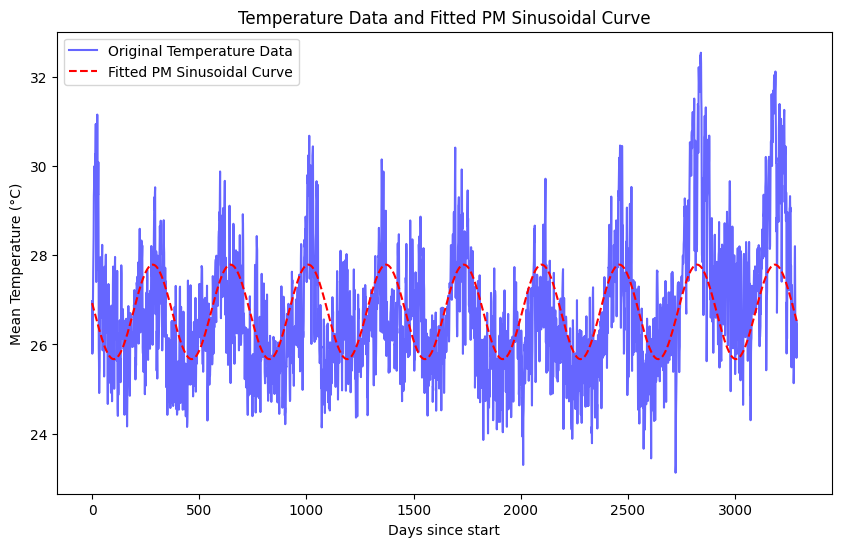

In [12]:
x_values_temp_pm = np.linspace(full_data_df['days'].min(), full_data_df['days'].max(), 500)

fitted_curve_temp_pm = sinusoidal_parham_michael(x_values_temp_pm, *params_temp_pm)

plt.figure(figsize=(10, 6))
plt.plot(full_data_df['days'], full_data_df['temp_med'], label="Original Temperature Data", color="blue", alpha=0.6)
plt.plot(x_values_temp_pm, fitted_curve_temp_pm, label="Fitted PM Sinusoidal Curve", color="red", linestyle="--")
plt.xlabel("Days since start")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Data and Fitted PM Sinusoidal Curve")
plt.legend()
plt.show()

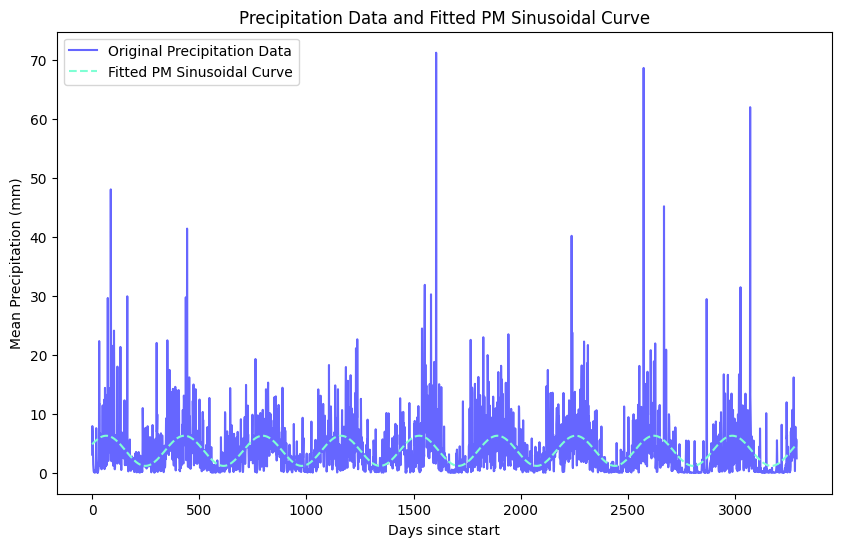

In [13]:
x_values_precip_pm = np.linspace(full_data_df['days'].min(), full_data_df['days'].max(), 500)

fitted_curve_precip_pm = sinusoidal_parham_michael(x_values_precip_pm, *params_precip_pm)

plt.figure(figsize=(10, 6))
plt.plot(full_data_df['days'], full_data_df['precip_med'], label="Original Precipitation Data", color="blue", alpha=0.6)
plt.plot(x_values_precip_pm, fitted_curve_precip_pm, label="Fitted PM Sinusoidal Curve", color="aquamarine", linestyle="--")
plt.xlabel("Days since start")
plt.ylabel("Mean Precipitation (mm)")
plt.title("Precipitation Data and Fitted PM Sinusoidal Curve")
plt.legend()
plt.show()

### Testing with other approximations

#### Fourier

In [16]:
def fourier_series(x, a0, a1, b1, a2, b2):
    return a0 + a1 * np.cos(2 * np.pi * x / 365) + b1 * np.sin(2 * np.pi * x / 365) + \
           a2 * np.cos(4 * np.pi * x / 365) + b2 * np.sin(4 * np.pi * x / 365)

In [17]:
# Fitting the model to the mean temperature data

params_fourier_temp, _ = curve_fit(fourier_series, full_data_df['days'], full_data_df['temp_med'])
fourier_curve_temp = fourier_series(full_data_df['days'], *params_fourier_temp)

print("Fitted Fourier parameters for temperature:", params_fourier_temp)

Fitted Fourier parameters for temperature: [ 2.67319626e+01 -2.59526196e-02 -1.05193550e+00 -5.08622593e-01
  1.32258059e-01]


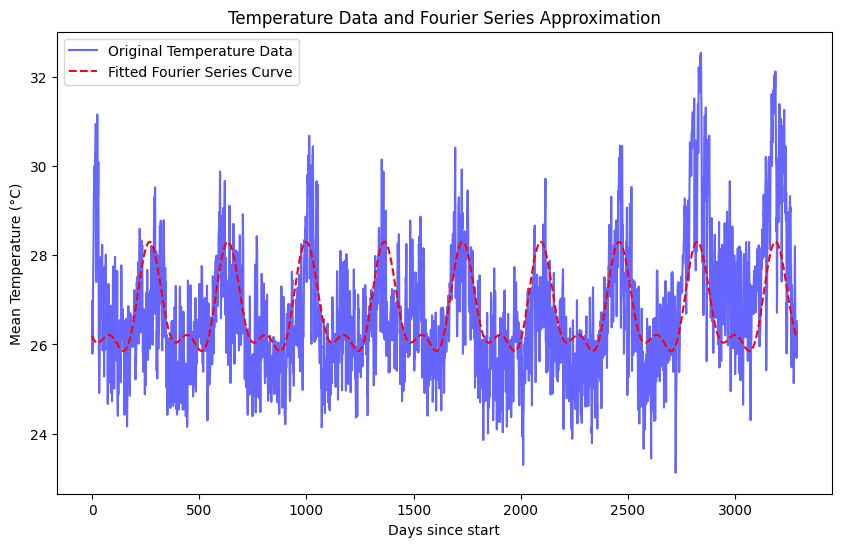

In [18]:
fitted_days = np.linspace(full_data_df['days'].min(), full_data_df['days'].max(), 500)
fitted_fourier_curve_temp = fourier_series(fitted_days, *params_fourier_temp)

# Plot the original data and the Fourier series approximation
plt.figure(figsize=(10, 6))
plt.plot(full_data_df['days'], full_data_df['temp_med'], label="Original Temperature Data", color="blue", alpha=0.6)
plt.plot(fitted_days, fitted_fourier_curve_temp, label="Fitted Fourier Series Curve", color="red", linestyle="--")
plt.xlabel("Days since start")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Data and Fourier Series Approximation")
plt.legend()
plt.show()

In [19]:
# Fitting the model to the mean precipitation data

params_fourier_precip, _ = curve_fit(fourier_series, full_data_df['days'], full_data_df['precip_med'])
fourier_curve_precip = fourier_series(full_data_df['days'], *params_fourier_precip)

print("Fitted Fourier parameters for precipitation:", params_fourier_precip)

Fitted Fourier parameters for precipitation: [ 3.71320626  1.07582725  2.3178642  -0.32656678 -0.69868805]


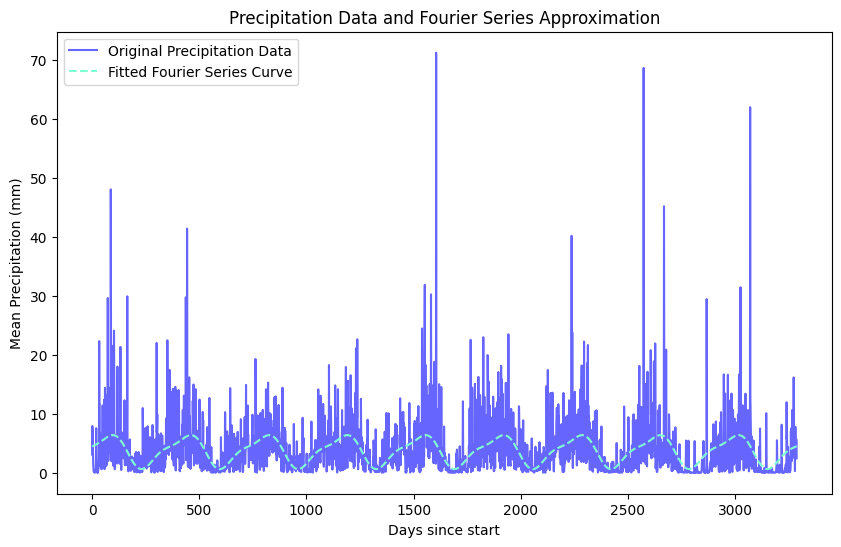

In [20]:
fitted_days = np.linspace(full_data_df['days'].min(), full_data_df['days'].max(), 500)
fitted_fourier_curve_precip = fourier_series(fitted_days, *params_fourier_precip)

# Plot the original data and the Fourier series approximation
plt.figure(figsize=(10, 6))
plt.plot(full_data_df['days'], full_data_df['precip_med'], label="Original Precipitation Data", color="blue", alpha=0.6)
plt.plot(fitted_days, fitted_fourier_curve_precip, label="Fitted Fourier Series Curve", color="aquamarine", linestyle="--")
plt.xlabel("Days since start")
plt.ylabel("Mean Precipitation (mm)")
plt.title("Precipitation Data and Fourier Series Approximation")
plt.legend()
plt.show()

#### Moving Average

In [22]:
climate_with_mov_avgs_weekly = full_data_df.copy()
climate_with_mov_avgs_monthly = full_data_df.copy()
climate_with_mov_avgs_yearly = full_data_df.copy()

climate_with_mov_avgs_weekly['temp_med_ma_weeks'] = climate_with_mov_avgs_weekly['temp_med'].rolling(window=int(7), center=True).mean()
climate_with_mov_avgs_weekly['precip_med_ma_weeks'] = climate_with_mov_avgs_weekly['precip_med'].rolling(window=int(7), center=True).mean()

climate_with_mov_avgs_monthly['temp_med_ma_months'] = climate_with_mov_avgs_monthly['temp_med'].rolling(window=int(30), center=True).mean()
climate_with_mov_avgs_monthly['precip_med_ma_months'] = climate_with_mov_avgs_monthly['precip_med'].rolling(window=int(30), center=True).mean()

climate_with_mov_avgs_yearly['temp_med_ma_years'] = climate_with_mov_avgs_yearly['temp_med'].rolling(window=int(365), center=True).mean()
climate_with_mov_avgs_yearly['precip_med_ma_years'] = climate_with_mov_avgs_yearly['precip_med'].rolling(window=int(365), center=True).mean()

climate_with_mov_avgs_monthly

,date,geocodigo,epiweek,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,precip_tot,pressao_min,pressao_med,pressao_max,umid_min,umid_med,umid_max,days,temp_med_ma_months,precip_med_ma_months
0,2016-01-01,1302603,201552,25.2045,26.9742,28.7045,0.2092,3.0621,6.9870,24.4965,0.9865,0.9892,0.9912,73.5599,83.5514,91.6022,0,NaN,NaN
1,2016-01-02,1302603,201552,24.7094,25.7935,26.7381,0.0388,7.8986,17.6067,63.1887,0.9880,0.9899,0.9922,86.0326,90.3434,95.2309,1,NaN,NaN
2,2016-01-03,1302603,201601,24.1877,25.8707,28.2754,1.1520,7.2728,20.6599,58.1821,0.9870,0.9897,0.9917,79.3838,90.4124,97.3460,2,NaN,NaN
3,2016-01-04,1302603,201601,24.2683,26.5175,29.6513,0.1548,6.1504,12.8499,49.2032,0.9866,0.9893,0.9914,72.0116,87.7519,96.4379,3,NaN,NaN
4,2016-01-05,1302603,201601,25.3694,27.0980,29.6138,0.0445,3.3259,8.8127,26.6074,0.9882,0.9898,0.9919,70.6908,85.9048,96.4212,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3283,2024-12-27,1302603,202452,24.3396,26.3144,29.6464,0.4375,4.4175,12.0925,35.3399,0.9873,0.9892,0.9908,72.7873,88.5445,95.8023,3283,NaN,NaN
3284,2024-12-28,1302603,202452,24.6078,26.4918,30.1530,0.8793,4.4093,13.8036,35.2744,0.9871,0.9898,0.9916,69.3192,88.2399,96.5652,3284,NaN,NaN
3285,2024-12-29,1302603,202501,25.0180,26.4557,28.5187,0.3675,5.6817,16.5503,45.4533,0.9875,0.9896,0.9918,80.2842,89.0658,94.7284,3285,NaN,NaN
3286,2024-12-30,1302603,202501,24.1221,25.7000,27.6957,0.1818,5.2545,16.7795,42.0363,0.9868,0.9894,0.9913,80.0111,89.6784,96.1786,3286,NaN,NaN


In [23]:
climate_with_mov_avgs_weekly_dropna = climate_with_mov_avgs_weekly.dropna(subset=['temp_med_ma_weeks', 'precip_med_ma_weeks'])
climate_with_mov_avgs_monthly_dropna = climate_with_mov_avgs_monthly.dropna(subset=['temp_med_ma_months', 'precip_med_ma_months'])
climate_with_mov_avgs_yearly_dropna = climate_with_mov_avgs_yearly.dropna(subset=['temp_med_ma_years', 'precip_med_ma_years'])

climate_with_mov_avgs_monthly_dropna

,date,geocodigo,epiweek,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,precip_tot,pressao_min,pressao_med,pressao_max,umid_min,umid_med,umid_max,days,temp_med_ma_months,precip_med_ma_months
15,2016-01-16,1302603,201602,26.7866,29.9790,33.2737,0.0018,0.0624,0.1448,0.4995,0.9848,0.9877,0.9899,53.5182,66.7319,81.8795,15,28.759330,1.663577
16,2016-01-17,1302603,201603,27.6955,30.5288,34.2751,0.0249,0.4580,0.7400,3.6638,0.9850,0.9876,0.9897,47.5061,65.8199,80.9632,16,28.811503,1.587850
17,2016-01-18,1302603,201603,28.1394,30.9489,34.1799,0.0045,0.1703,0.7407,1.3625,0.9845,0.9874,0.9891,47.0556,62.3828,77.9552,17,28.815560,1.432137
18,2016-01-19,1302603,201603,27.4386,29.4930,31.7202,0.1485,2.6231,6.1295,20.9847,0.9858,0.9880,0.9900,61.8295,72.1374,85.1701,18,28.806660,1.460503
19,2016-01-20,1302603,201603,24.3394,27.4030,30.8717,1.6755,7.5500,9.3520,60.4003,0.9868,0.9892,0.9910,65.6500,81.7762,94.6067,19,28.753100,1.998880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3269,2024-12-13,1302603,202450,24.5443,26.1533,28.1690,0.2517,4.3829,9.9107,35.0633,0.9853,0.9881,0.9902,81.7500,89.3454,95.9387,3269,27.075710,4.210983
3270,2024-12-14,1302603,202450,24.2428,26.0419,28.3255,0.0058,4.5357,11.7660,36.2859,0.9853,0.9877,0.9898,76.1371,87.6908,95.0013,3270,26.990703,4.338413
3271,2024-12-15,1302603,202451,24.0798,26.3654,29.4264,0.0000,3.7107,12.3677,29.6857,0.9860,0.9882,0.9902,72.6114,86.1816,95.3753,3271,26.903030,4.525573
3272,2024-12-16,1302603,202451,24.9720,26.9026,29.7163,0.0024,2.6001,10.2647,20.8007,0.9871,0.9890,0.9910,67.5808,83.4051,93.5355,3272,26.782060,4.695737


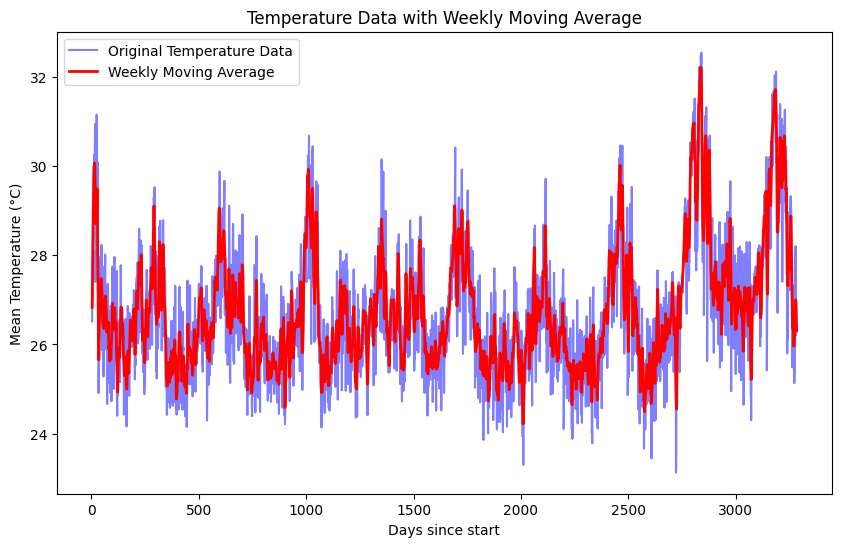

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(climate_with_mov_avgs_weekly_dropna['days'], climate_with_mov_avgs_weekly_dropna['temp_med'], label="Original Temperature Data", color="blue", alpha=0.5)
plt.plot(climate_with_mov_avgs_weekly_dropna['days'], climate_with_mov_avgs_weekly_dropna['temp_med_ma_weeks'], label="Weekly Moving Average", color="red", linewidth=2)
plt.xlabel("Days since start")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Data with Weekly Moving Average")
plt.legend()
plt.show()

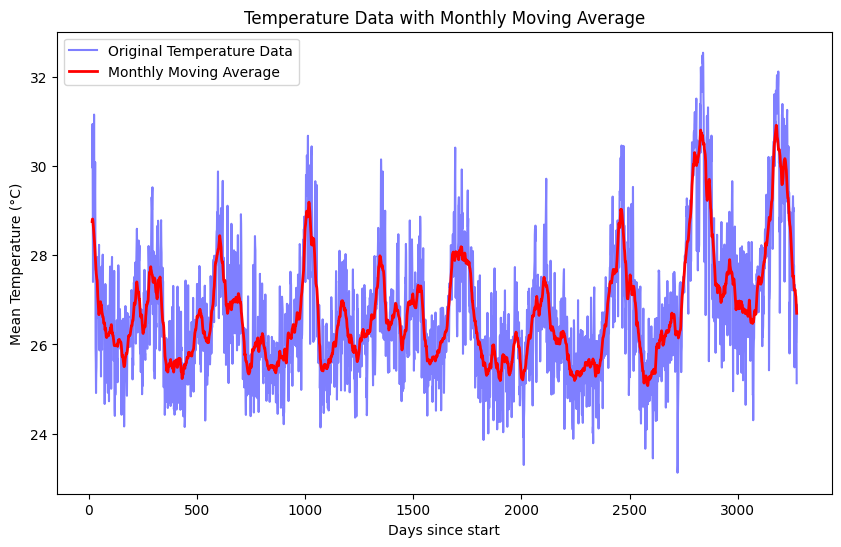

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(climate_with_mov_avgs_monthly_dropna['days'], climate_with_mov_avgs_monthly_dropna['temp_med'], label="Original Temperature Data", color="blue", alpha=0.5)
plt.plot(climate_with_mov_avgs_monthly_dropna['days'], climate_with_mov_avgs_monthly_dropna['temp_med_ma_months'], label="Monthly Moving Average", color="red", linewidth=2)
plt.xlabel("Days since start")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Data with Monthly Moving Average")
plt.legend()
plt.show()

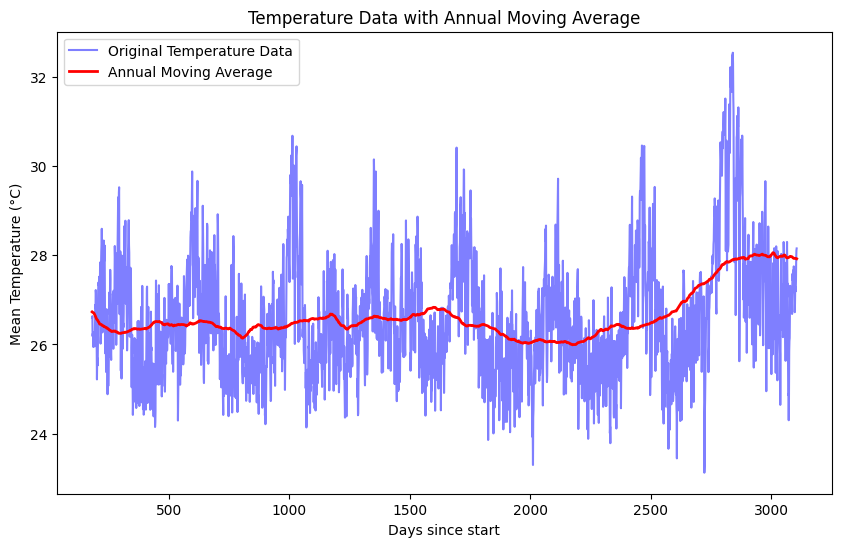

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(climate_with_mov_avgs_yearly_dropna['days'], climate_with_mov_avgs_yearly_dropna['temp_med'], label="Original Temperature Data", color="blue", alpha=0.5)
plt.plot(climate_with_mov_avgs_yearly_dropna['days'], climate_with_mov_avgs_yearly_dropna['temp_med_ma_years'], label="Annual Moving Average", color="red", linewidth=2)
plt.xlabel("Days since start")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Data with Annual Moving Average")
plt.legend()
plt.show()

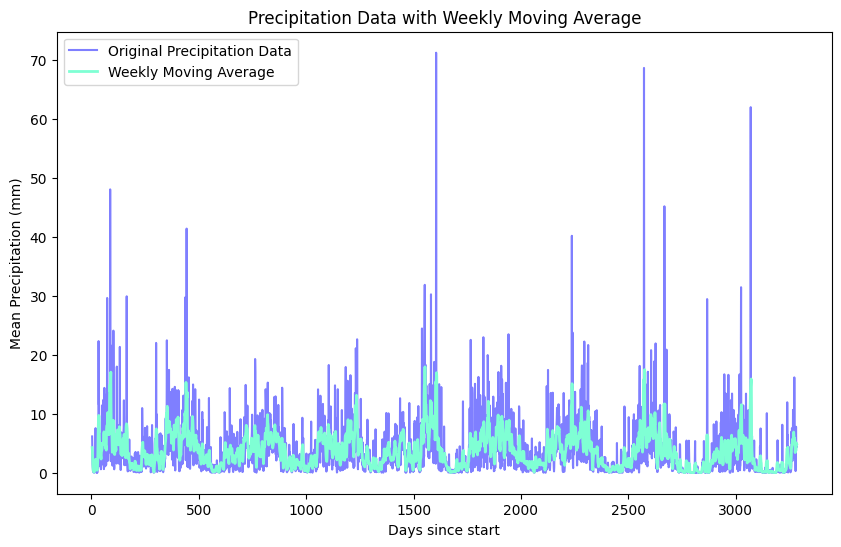

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(climate_with_mov_avgs_weekly_dropna['days'], climate_with_mov_avgs_weekly_dropna['precip_med'], label="Original Precipitation Data", color="blue", alpha=0.5)
plt.plot(climate_with_mov_avgs_weekly_dropna['days'], climate_with_mov_avgs_weekly_dropna['precip_med_ma_weeks'], label="Weekly Moving Average", color="aquamarine", linewidth=2)
plt.xlabel("Days since start")
plt.ylabel("Mean Precipitation (mm)")
plt.title("Precipitation Data with Weekly Moving Average")
plt.legend()
plt.show()

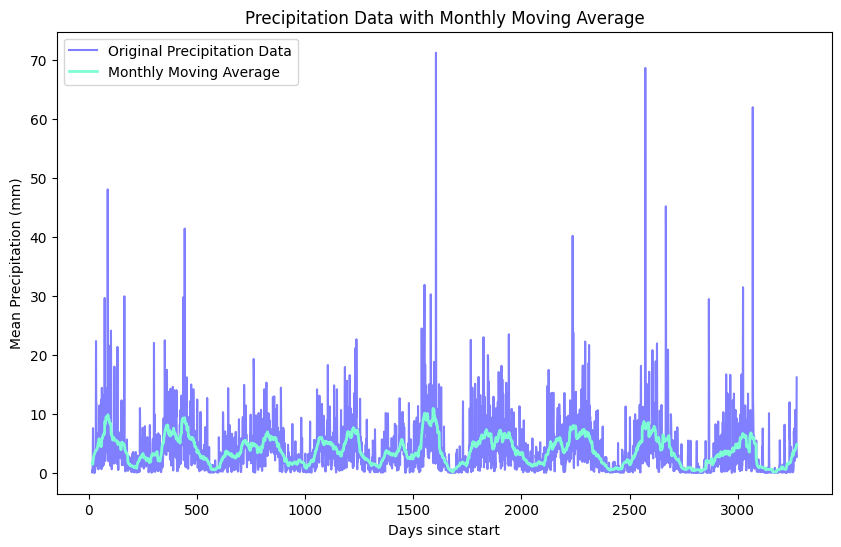

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(climate_with_mov_avgs_monthly_dropna['days'], climate_with_mov_avgs_monthly_dropna['precip_med'], label="Original Precipitation Data", color="blue", alpha=0.5)
plt.plot(climate_with_mov_avgs_monthly_dropna['days'], climate_with_mov_avgs_monthly_dropna['precip_med_ma_months'], label="Monthly Moving Average", color="aquamarine", linewidth=2)
plt.xlabel("Days since start")
plt.ylabel("Mean Precipitation (mm)")
plt.title("Precipitation Data with Monthly Moving Average")
plt.legend()
plt.show()

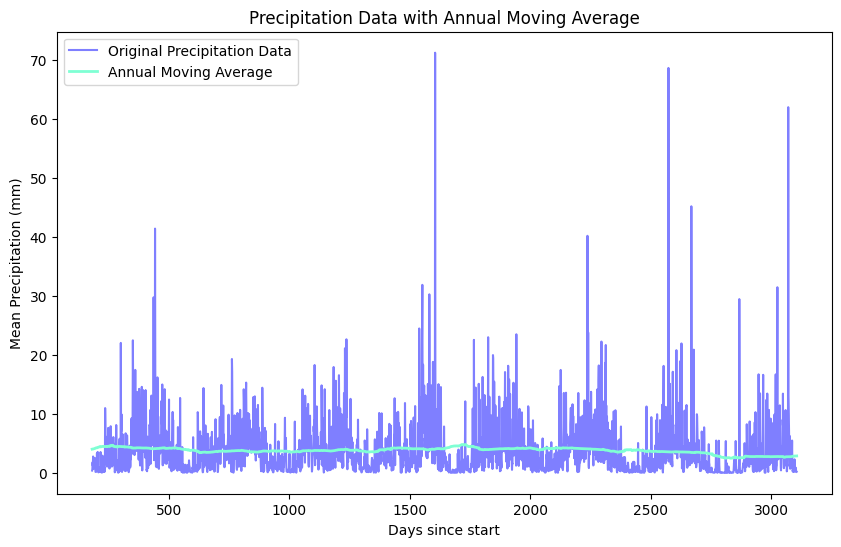

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(climate_with_mov_avgs_yearly_dropna['days'], climate_with_mov_avgs_yearly_dropna['precip_med'], label="Original Precipitation Data", color="blue", alpha=0.5)
plt.plot(climate_with_mov_avgs_yearly_dropna['days'], climate_with_mov_avgs_yearly_dropna['precip_med_ma_years'], label="Annual Moving Average", color="aquamarine", linewidth=2)
plt.xlabel("Days since start")
plt.ylabel("Mean Precipitation (mm)")
plt.title("Precipitation Data with Annual Moving Average")
plt.legend()
plt.show()

In [57]:
page = 1 # total amount of pages is returned in the request
per_page = 100
pagination = f"?page={page}&per_page={per_page}&"
filters = "start=%s&end=%s" % ("2003-08-01", "2004-07-31")

resp = requests.get(climate_api + pagination + filters)

load_dotenv(encoding="utf-16")

api_key = os.getenv("MOSQLIMATE_API_KEY")

headers = {
    "X-UID-Key": api_key
}

# Or you can add a geocode to the filters
geocode = 1302603
resp = requests.get(
    climate_api + 
    pagination + 
    filters +
    f"&geocode={geocode}",
    headers=headers
)

items = resp.json()["items"] # JSON data in dict format
#total_items = resp.json()["total_items"] # JSON data in dict format
resp.json()["pagination"] # Pagination*

{'items': 100,
 'total_items': 366,
 'page': 1,
 'total_pages': 4,
 'per_page': 100}

In [59]:
total_pages = 4

start_date = "2003-08-01"
end_date = "2004-07-31"

geocode = 1302603

all_items = []  # List to store all items

# Loop through each page
for page in range(1, total_pages + 1):
    pagination = f"?page={page}&per_page={per_page}&"
    filters = f"start={start_date}&end={end_date}&geocode={geocode}"
    
    resp = requests.get(climate_api + pagination + filters, headers=headers)
    
    # Check if the request was successful
    if resp.status_code == 200:
        items = resp.json().get("items", [])  # Get items, default to an empty list if key not found
        all_items.extend(items)  # Append the items from this page to the list
    else:
        print(f"Failed to retrieve data for page {page}")
        break  # Break the loop in case of a failed request

full_data_df = pd.DataFrame(all_items)
full_data_df

,date,geocodigo,epiweek,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,precip_tot,pressao_min,pressao_med,pressao_max,umid_min,umid_med,umid_max
0,2003-08-01,1302603,200331,23.3116,26.0381,28.9861,1.1569,2.7523,4.3140,22.0185,0.9887,0.9913,0.9933,71.5405,85.9018,96.1144
1,2003-08-02,1302603,200331,23.5793,25.5687,27.9327,0.0221,4.6876,12.2416,37.5009,0.9898,0.9917,0.9935,80.3964,89.1108,96.7462
2,2003-08-03,1302603,200332,23.5488,25.8723,29.9776,0.0189,2.4695,12.3043,19.7559,0.9890,0.9920,0.9935,71.6096,89.1706,98.0317
3,2003-08-04,1302603,200332,23.4368,25.8582,29.1867,0.0200,1.2006,4.7839,9.6052,0.9881,0.9914,0.9933,73.2576,88.2373,97.6056
4,2003-08-05,1302603,200332,23.4715,26.4096,30.2010,0.0271,0.5638,1.7643,4.5105,0.9871,0.9905,0.9922,69.2458,85.7391,96.3157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2004-07-27,1302603,200430,22.8200,25.4296,28.8375,0.5279,2.0156,3.7123,16.1250,0.9894,0.9926,0.9946,70.5683,85.2249,94.2395
362,2004-07-28,1302603,200430,22.8407,25.8917,29.5574,0.2723,0.7282,3.0715,5.8258,0.9892,0.9916,0.9933,63.7718,82.9870,96.4385
363,2004-07-29,1302603,200430,23.2566,26.2979,29.9400,0.0000,0.1727,0.7810,1.3816,0.9893,0.9913,0.9929,59.9819,80.4510,93.2805
364,2004-07-30,1302603,200430,23.2459,26.4038,30.1195,0.0000,0.2266,1.1694,1.8131,0.9900,0.9922,0.9940,64.3335,81.7540,95.4840


In [61]:
# Saves the dataframe as a separate csv file to be used in different modules
full_data_df.to_csv("../data/climate_api_data_aug_2003_jul_2004.csv", index=False)

In [7]:
page = 1 # total amount of pages is returned in the request
per_page = 100
pagination = f"?page={page}&per_page={per_page}&"
filters = "start=%s&end=%s" % ("2012-01-01", "2015-12-31")

resp = requests.get(climate_api + pagination + filters)

load_dotenv(encoding="utf-16")

api_key = os.getenv("MOSQLIMATE_API_KEY")

headers = {
    "X-UID-Key": api_key
}

# Or you can add a geocode to the filters
geocode = 1302603
resp = requests.get(
    climate_api + 
    pagination + 
    filters +
    f"&geocode={geocode}",
    headers=headers
)

items = resp.json()["items"] # JSON data in dict format
#total_items = resp.json()["total_items"] # JSON data in dict format
resp.json()["pagination"] # Pagination*

{'items': 100,
 'total_items': 1461,
 'page': 1,
 'total_pages': 15,
 'per_page': 100}

In [9]:
#### Getting the full data:

pages = np.arange(1, 16) # total amount of pages is returned in the request
per_page = 100
for page in pages:
    pagination = f"?page={page}&per_page={per_page}&"
    filters = "start=%s&end=%s" % ("2012-01-01", "2015-12-31")

    resp = requests.get(climate_api + pagination + filters)

# Or you can add a geocode to the filters
geocode = 1302603
resp = requests.get(
    climate_api + 
    pagination + 
    filters +
    f"&geocode={geocode}",
    headers=headers
)

items = resp.json()["items"] # JSON data in dict format
#total_items = resp.json()["total_items"] # JSON data in dict format
resp.json()["pagination"] # Pagination*

{'items': 61,
 'total_items': 1461,
 'page': 15,
 'total_pages': 15,
 'per_page': 100}

In [13]:
total_pages = 15

start_date = "2012-01-01"
end_date = "2015-12-31"

geocode = 1302603

all_items = []  # List to store all items

# Loop through each page
for page in range(1, total_pages + 1):
    pagination = f"?page={page}&per_page={per_page}&"
    filters = f"start={start_date}&end={end_date}&geocode={geocode}"
    
    resp = requests.get(climate_api + pagination + filters, headers=headers)
    
    # Check if the request was successful
    if resp.status_code == 200:
        items = resp.json().get("items", [])  # Get items, default to an empty list if key not found
        all_items.extend(items)  # Append the items from this page to the list
    else:
        print(f"Failed to retrieve data for page {page}")
        break  # Break the loop in case of a failed request

full_data_df = pd.DataFrame(all_items)
full_data_df

,date,geocodigo,epiweek,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,precip_tot,pressao_min,pressao_med,pressao_max,umid_min,umid_med,umid_max
0,2012-01-01,1302603,201201,23.5776,26.4358,29.4713,0.0034,2.4919,14.1971,19.9353,0.9863,0.9893,0.9915,71.9257,84.9614,96.8463
1,2012-01-02,1302603,201201,24.4484,26.1401,28.0239,0.0708,2.3304,5.7423,18.6432,0.9871,0.9891,0.9910,78.7056,87.9689,96.3509
2,2012-01-03,1302603,201201,24.0368,25.4864,27.2661,0.3982,5.1823,12.5032,41.4585,0.9879,0.9896,0.9914,78.5467,89.9032,97.3886
3,2012-01-04,1302603,201201,23.7427,25.2420,26.4635,0.0107,7.4390,16.2924,59.5116,0.9891,0.9908,0.9928,83.7411,90.3928,97.3329
4,2012-01-05,1302603,201201,23.5689,25.3387,28.7727,0.0793,3.2862,16.7249,26.2898,0.9874,0.9901,0.9922,78.2364,89.3147,96.7769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2015-12-27,1302603,201552,24.9218,27.4113,30.3556,0.0122,1.2347,2.8379,9.8775,0.9848,0.9883,0.9908,65.5195,82.0649,94.1325
1457,2015-12-28,1302603,201552,25.4784,27.3410,29.2601,0.0064,2.8136,8.2316,22.5086,0.9859,0.9883,0.9905,72.3488,81.7808,90.1505
1458,2015-12-29,1302603,201552,25.1607,27.2963,30.5930,0.8681,10.9582,15.7956,87.6653,0.9881,0.9906,0.9934,68.0563,84.5570,94.2341
1459,2015-12-30,1302603,201552,24.7802,27.3755,30.6458,3.7034,14.5861,17.7077,116.6891,0.9887,0.9918,0.9941,67.7770,83.5633,95.7584


In [15]:
# Saves the dataframe as a separate csv file to be used in different modules
full_data_df.to_csv("../data/climate_api_data_2012_2015.csv", index=False)